#### Supp. Fig 3c, d

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
import os
import scanpy as sc  
import numpy as np 
import matplotlib.pyplot as plt 
import matplotlib as mpl 
import cell2location 
import pandas as pd
import seaborn as sns  
import pandas as pd  
import random
import statsmodels.api as sm
pd.set_option('display.max_columns',400)
pd.set_option('display.max_categories',40)
# Set general parameters for publication-ready figures
plt.rcParams.update({
    'pdf.fonttype': 42,
    'font.family': 'Arial',  # Set font to Arial
    'font.size': 14,  # Set font size to at least 14
    'axes.labelsize': 14,  # Axes labels size
    'axes.titlesize': 16,  # Title size for axes
    'xtick.labelsize': 14,  # X-tick label size
    'ytick.labelsize': 14,  # Y-tick label size
    'legend.fontsize': 14,  # Legend font size
    'figure.titlesize': 16,  # Figure title size
    'lines.linewidth': 2,  # Line width for clarity
    'axes.linewidth': 1.5,  # Axis line width
    'xtick.major.width': 1.5,
    'ytick.major.width': 1.5,
    'text.color': 'black',  # Make sure text is black (not grey)
    'axes.labelcolor': 'black',  # Ensure axes labels are black
    'axes.edgecolor': 'black',  # Ensure edge of axes is black
    'xtick.color': 'black',  # Ensure X-tick marks are black
    'ytick.color': 'black',  # Ensure Y-tick marks are black
    'axes.titlepad': 20  # Padding for title

})

save_dir = "boxplot_normalized_to_total_cell_abundance_Banovich_Kropski_2020"
# Create the directory if it doesn't exist
os.makedirs(save_dir, exist_ok=True)

boxprops=dict(edgecolor="black")
whiskerprops=dict(color="black")
capprops=dict(color='black')
medianprops=dict(color='black')



In [3]:
adata_vis = sc.read_h5ad("/Users/jk/Documents/Lab2/visium/python_analysis/local_401/h5ad/adata_vis_assigned_cell_types_Banovich_Kropski_2020.h5ad")


In [3]:
adata_vis.obs

,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,probe_date,probe_lot,probe_group,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes,training_batch,AT1,AT2,B Cells,Basal,Ciliated,Differentiating Ciliated,Endothelial Cells,Fibroblasts,HAS1 High Fibroblasts,KRT5-/KRT17+,Lymphatic Endothelial Cells,MUC5AC+ High,MUC5B+,Macrophages,Mast Cells,Mesothelial Cells,Monocytes,Myofibroblasts,NK Cells,PLIN2+ Fibroblasts,Plasma Cells,Proliferating Epithelial Cells,Proliferating Macrophages,Proliferating T Cells,SCGB3A2+,SCGB3A2+ SCGB1A1+,Smooth Muscle Cells,T Cells,Transitional AT2,cDCs,pDCs,cell_type_assigned
AACACGTGCATCGCAC-1-18_57617_A1,1.0,76.0,22.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3961,8.284504,7804.0,8.962520,31.765761,35.212711,39.928242,49.410559,629.0,6.445720,8.059970,0.0,0.0,0.0,0.0,0.0,0.0,7804.0,3961,1,0.000121,0.000058,2.606759,0.021888,0.022712,0.000765,0.008533,0.490488,0.000365,0.000324,0.010266,0.016283,0.000135,0.001216,0.004710,0.001310,0.001619,0.137825,0.005397,0.037551,0.839984,0.000634,0.001651,0.028412,0.000168,0.000388,0.069938,0.005788,0.000043,0.007476,0.374214,B Cells
AACACTTGGCAAGGAA-1-18_57617_A1,1.0,47.0,71.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3322,8.108623,5412.0,8.596559,15.909091,20.842572,27.475979,40.742794,280.0,5.638355,5.173688,0.0,0.0,0.0,0.0,0.0,0.0,5412.0,3322,0,0.655921,0.198965,0.043134,0.014921,0.245940,0.142327,1.814419,0.329892,0.004692,0.015789,0.071004,0.006722,0.040376,0.249612,0.033158,0.025635,0.116833,0.534052,0.033749,0.011183,0.009671,0.008672,0.347197,0.115536,0.038632,0.158811,0.661079,0.052495,0.032026,0.059528,0.022794,Endothelial Cells
AACAGGATTCATAGTT-1-18_57617_A1,1.0,49.0,43.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,2120,7.659643,3313.0,8.105911,26.048898,30.878358,37.488681,51.101720,538.0,6.289716,16.239059,0.0,0.0,0.0,0.0,0.0,0.0,3313.0,2120,1,0.030476,0.053324,0.007877,0.003653,0.006319,0.001834,3.519053,0.011722,0.001407,0.011260,0.038761,0.002860,0.001043,0.025898,0.041071,0.005284,0.016251,0.147765,0.018327,0.001197,0.001651,0.001984,0.033813,0.113669,0.001416,0.001710,0.168641,0.044654,0.008228,0.298027,0.043349,Endothelial Cells
AACAGGTTCACCGAAG-1-18_57617_A1,1.0,51.0,41.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,2388,7.778630,3665.0,8.206857,25.702592,29.795362,35.470668,48.485675,697.0,6.548219,19.017735,0.0,0.0,0.0,0.0,0.0,0.0,3665.0,2388,0,0.018140,0.038160,0.130789,0.008995,0.100701,0.000965,2.517719,0.017408,0.001519,0.000873,0.031150,0.000187,0.000143,0.018854,0.024677,0.004400,0.035601,0.051447,0.020844,0.001504,0.003595,0.001810,0.001683,0.456863,0.000717,0.000940,0.052566,0.020904,0.000685,0.004307,0.009843,Endothelial Cells
AACAGTCAGGCTCCGC-1-18_57617_A1,1.0,24.0,6.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,4939,8.505121,10317.0,9.241645,17.514781,22.545314,28.777745,40.544732,498.0,6.212606,4.826984,0.0,0

In [4]:
# adata_file = f"{run_name}/sp.h5ad"
# adata_vis = sc.read_h5ad(adata_file)
# adata_vis = adata_vis.raw.to_adata()

In [5]:
adata_vis

AnnData object with n_obs × n_vars = 160702 × 16959
    obs: 'in_tissue', 'array_row', 'array_col', 'library_id', 'alignment', 'desired_rc', 'actual_rc', 'xmin', 'xmax', 'ymin', 'ymax', 'hpx', 'vpx', 'slide', 'area', 'date', 'cytassist_ver', 'seq_batch', 'probe_date', 'probe_lot', 'probe_group', 'cond', 'cond_rep', 'rep', 'age ', 'sex', 'bmi', 'packyears', 'FVC', 'DLCO', '6MWD', 'outcome_long', 'tte_long', 'outcome_24m', 'tte_24m', 'lobe_lr', 'lobe', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts', 'n_genes', 'training_batch', 'AT1', 'AT2', 'B Cells', 'Basal', 'Ciliated', 'Differentiating Ciliated', 'Endothelial Cells', 'Fibroblast

In [6]:
adata_vis.obs

,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,probe_date,probe_lot,probe_group,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes,training_batch,AT1,AT2,B Cells,Basal,Ciliated,Differentiating Ciliated,Endothelial Cells,Fibroblasts,HAS1 High Fibroblasts,KRT5-/KRT17+,Lymphatic Endothelial Cells,MUC5AC+ High,MUC5B+,Macrophages,Mast Cells,Mesothelial Cells,Monocytes,Myofibroblasts,NK Cells,PLIN2+ Fibroblasts,Plasma Cells,Proliferating Epithelial Cells,Proliferating Macrophages,Proliferating T Cells,SCGB3A2+,SCGB3A2+ SCGB1A1+,Smooth Muscle Cells,T Cells,Transitional AT2,cDCs,pDCs,cell_type_assigned
AACACGTGCATCGCAC-1-18_57617_A1,1.0,76.0,22.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3961,8.284504,7804.0,8.962520,31.765761,35.212711,39.928242,49.410559,629.0,6.445720,8.059970,0.0,0.0,0.0,0.0,0.0,0.0,7804.0,3961,1,0.000121,0.000058,2.606759,0.021888,0.022712,0.000765,0.008533,0.490488,0.000365,0.000324,0.010266,0.016283,0.000135,0.001216,0.004710,0.001310,0.001619,0.137825,0.005397,0.037551,0.839984,0.000634,0.001651,0.028412,0.000168,0.000388,0.069938,0.005788,0.000043,0.007476,0.374214,B Cells
AACACTTGGCAAGGAA-1-18_57617_A1,1.0,47.0,71.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3322,8.108623,5412.0,8.596559,15.909091,20.842572,27.475979,40.742794,280.0,5.638355,5.173688,0.0,0.0,0.0,0.0,0.0,0.0,5412.0,3322,0,0.655921,0.198965,0.043134,0.014921,0.245940,0.142327,1.814419,0.329892,0.004692,0.015789,0.071004,0.006722,0.040376,0.249612,0.033158,0.025635,0.116833,0.534052,0.033749,0.011183,0.009671,0.008672,0.347197,0.115536,0.038632,0.158811,0.661079,0.052495,0.032026,0.059528,0.022794,Endothelial Cells
AACAGGATTCATAGTT-1-18_57617_A1,1.0,49.0,43.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,2120,7.659643,3313.0,8.105911,26.048898,30.878358,37.488681,51.101720,538.0,6.289716,16.239059,0.0,0.0,0.0,0.0,0.0,0.0,3313.0,2120,1,0.030476,0.053324,0.007877,0.003653,0.006319,0.001834,3.519053,0.011722,0.001407,0.011260,0.038761,0.002860,0.001043,0.025898,0.041071,0.005284,0.016251,0.147765,0.018327,0.001197,0.001651,0.001984,0.033813,0.113669,0.001416,0.001710,0.168641,0.044654,0.008228,0.298027,0.043349,Endothelial Cells
AACAGGTTCACCGAAG-1-18_57617_A1,1.0,51.0,41.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,2388,7.778630,3665.0,8.206857,25.702592,29.795362,35.470668,48.485675,697.0,6.548219,19.017735,0.0,0.0,0.0,0.0,0.0,0.0,3665.0,2388,0,0.018140,0.038160,0.130789,0.008995,0.100701,0.000965,2.517719,0.017408,0.001519,0.000873,0.031150,0.000187,0.000143,0.018854,0.024677,0.004400,0.035601,0.051447,0.020844,0.001504,0.003595,0.001810,0.001683,0.456863,0.000717,0.000940,0.052566,0.020904,0.000685,0.004307,0.009843,Endothelial Cells
AACAGTCAGGCTCCGC-1-18_57617_A1,1.0,24.0,6.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,4939,8.505121,10317.0,9.241645,17.514781,22.545314,28.777745,40.544732,498.0,6.212606,4.826984,0.0,0

In [ ]:
adata_vis.obs[adata_vis.uns['mod_0']['factor_names']] = adata_vis.obsm['q05_cell_abundance_w_sf']
adata_vis.obs[adata_vis.uns['mod_1']['factor_names']] = adata_vis.obsm['q05_cell_abundance_w_sf']

In [8]:
adata_vis.uns

{'mod_0': {'date': '2025-07-13',
  'factor_filter': array([], dtype=float64),
  'factor_names': array(['AT1', 'AT2', 'B Cells', 'Basal', 'Ciliated',
         'Differentiating Ciliated', 'Endothelial Cells', 'Fibroblasts',
         'HAS1 High Fibroblasts', 'KRT5-/KRT17+',
         'Lymphatic Endothelial Cells', 'MUC5AC+ High', 'MUC5B+',
         'Macrophages', 'Mast Cells', 'Mesothelial Cells', 'Monocytes',
         'Myofibroblasts', 'NK Cells', 'PLIN2+ Fibroblasts', 'Plasma Cells',
         'Proliferating Epithelial Cells', 'Proliferating Macrophages',
         'Proliferating T Cells', 'SCGB3A2+', 'SCGB3A2+ SCGB1A1+',
         'Smooth Muscle Cells', 'T Cells', 'Transitional AT2', 'cDCs',
         'pDCs'], dtype=object),
  'model_name': 'Cell2locationBaseModule',
  'obs_names': array(['AACACTTGGCAAGGAA-1-18_57617_A1', 'AACAGGTTCACCGAAG-1-18_57617_A1',
         'AACATAGTCTATCTAC-1-18_57617_A1', ...,
         'TGTTGGAAGCTCGGTA-1-22_16220_B1', 'TGTTGGATGGACTTCT-1-22_16220_B1',
         'TG

In [9]:
adata_vis.obsm["q05_cell_abundance_w_sf"]

array([[1.21440680e-04, 5.83787623e-05, 2.60675931e+00, ...,
        4.31198932e-05, 7.47587066e-03, 3.74214262e-01],
       [6.55920923e-01, 1.98964879e-01, 4.31340560e-02, ...,
        3.20258141e-02, 5.95281720e-02, 2.27936246e-02],
       [3.04761138e-02, 5.33235632e-02, 7.87736382e-03, ...,
        8.22779909e-03, 2.98026979e-01, 4.33493741e-02],
       ...,
       [1.18010275e-01, 7.02984989e-01, 6.94371462e-02, ...,
        7.60639384e-02, 3.15684110e-01, 1.83565374e-02],
       [1.42286077e-01, 1.71798337e+00, 1.57649461e-02, ...,
        6.82351738e-02, 6.07999861e-02, 7.55491257e-02],
       [2.03007746e+00, 1.50557756e-01, 2.41461117e-02, ...,
        2.28380227e+00, 3.73256505e-02, 7.97027722e-03]])

In [10]:
adata_vis.uns['mod'] = adata_vis.uns['mod_0']

In [11]:
df = sc.get.obs_df(adata_vis, keys = list(adata_vis.obs.columns)).reset_index()

In [12]:
ct = adata_vis.uns["mod_0"]['factor_names']

In [13]:
df.groupby("library_id")[['cond','rep']].head(5)

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_2696/1927378212.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("library_id")[['cond','rep']].head(5)


,cond,rep
0,IPF,1
1,IPF,1
2,IPF,1
3,IPF,1
4,IPF,1
...,...,...
157825,IPF,10
157826,IPF,10
157827,IPF,10
157828,IPF,10


In [14]:
df

,index,in_tissue,array_row,array_col,library_id,alignment,desired_rc,actual_rc,xmin,xmax,ymin,ymax,hpx,vpx,slide,area,date,cytassist_ver,seq_batch,probe_date,probe_lot,probe_group,cond,cond_rep,rep,age,sex,bmi,packyears,FVC,DLCO,6MWD,outcome_long,tte_long,outcome_24m,tte_24m,lobe_lr,lobe,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,log1p_total_counts_mt,pct_counts_mt,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,n_genes,training_batch,AT1,AT2,B Cells,Basal,Ciliated,Differentiating Ciliated,Endothelial Cells,Fibroblasts,HAS1 High Fibroblasts,KRT5-/KRT17+,Lymphatic Endothelial Cells,MUC5AC+ High,MUC5B+,Macrophages,Mast Cells,Mesothelial Cells,Monocytes,Myofibroblasts,NK Cells,PLIN2+ Fibroblasts,Plasma Cells,Proliferating Epithelial Cells,Proliferating Macrophages,Proliferating T Cells,SCGB3A2+,SCGB3A2+ SCGB1A1+,Smooth Muscle Cells,T Cells,Transitional AT2,cDCs,pDCs,cell_type_assigned
0,AACACGTGCATCGCAC-1-18_57617_A1,1.0,76.0,22.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3961,8.284504,7804.0,8.962520,31.765761,35.212711,39.928242,49.410559,629.0,6.445720,8.059970,0.0,0.0,0.0,0.0,0.0,0.0,7804.0,3961,1,0.000121,0.000058,2.606759,0.021888,0.022712,0.000765,0.008533,0.490488,0.000365,0.000324,0.010266,0.016283,0.000135,0.001216,0.004710,0.001310,0.001619,0.137825,0.005397,0.037551,0.839984,0.000634,0.001651,0.028412,0.000168,0.000388,0.069938,0.005788,0.000043,0.007476,0.374214,B Cells
1,AACACTTGGCAAGGAA-1-18_57617_A1,1.0,47.0,71.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,3322,8.108623,5412.0,8.596559,15.909091,20.842572,27.475979,40.742794,280.0,5.638355,5.173688,0.0,0.0,0.0,0.0,0.0,0.0,5412.0,3322,0,0.655921,0.198965,0.043134,0.014921,0.245940,0.142327,1.814419,0.329892,0.004692,0.015789,0.071004,0.006722,0.040376,0.249612,0.033158,0.025635,0.116833,0.534052,0.033749,0.011183,0.009671,0.008672,0.347197,0.115536,0.038632,0.158811,0.661079,0.052495,0.032026,0.059528,0.022794,Endothelial Cells
2,AACAGGATTCATAGTT-1-18_57617_A1,1.0,49.0,43.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,2120,7.659643,3313.0,8.105911,26.048898,30.878358,37.488681,51.101720,538.0,6.289716,16.239059,0.0,0.0,0.0,0.0,0.0,0.0,3313.0,2120,1,0.030476,0.053324,0.007877,0.003653,0.006319,0.001834,3.519053,0.011722,0.001407,0.011260,0.038761,0.002860,0.001043,0.025898,0.041071,0.005284,0.016251,0.147765,0.018327,0.001197,0.001651,0.001984,0.033813,0.113669,0.001416,0.001710,0.168641,0.044654,0.008228,0.298027,0.043349,Endothelial Cells
3,AACAGGTTCACCGAAG-1-18_57617_A1,1.0,51.0,41.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,2388,7.778630,3665.0,8.206857,25.702592,29.795362,35.470668,48.485675,697.0,6.548219,19.017735,0.0,0.0,0.0,0.0,0.0,0.0,3665.0,2388,0,0.018140,0.038160,0.130789,0.008995,0.100701,0.000965,2.517719,0.017408,0.001519,0.000873,0.031150,0.000187,0.000143,0.018854,0.024677,0.004400,0.035601,0.051447,0.020844,0.001504,0.003595,0.001810,0.001683,0.456863,0.000717,0.000940,0.052566,0.020904,0.000685,0.004307,0.009843,Endothelial Cells
4,AACAGTCAGGCTCCGC-1-18_57617_A1,1.0,24.0,6.0,18_57617_A1,auto,75,85,0,0,0,520,14965,14865,V43L25-333,D1,2023-12-06,1.1.5.551,1,2023-09-01,203531,1,IPF,IPF_1,1,77,M,29,10.0,70.0,32.0,413.0,DEAD,23,DEAD,23,left,upper,4939,8.505121,10317.0,9.241645,17.514781,22.545314,28.777745,40.544732,498.0,6.21260

In [15]:
df[df['AT1'] >= 1].groupby('library_id')['AT1'].sum()

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_2696/804251560.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df['AT1'] >= 1].groupby('library_id')['AT1'].sum()


library_id
06_30914_A1       75.833574
08_38774_B2       11.370376
11_13888_A1     2584.741596
12_39986_A2       78.196631
16_39724_B1     1181.706578
16_46257_A1      192.118017
16_53837_A10      42.519079
17_25789_B1      409.639463
17_35291_B1        0.000000
18_23779_A2        3.668935
18_57617_A1      507.128263
19_18542_A4       94.045087
19_35057_C3     1429.954847
19_48719_A1        0.000000
20_12743_C1       42.819000
20_17688_B2       30.821708
20_22642_A1       11.996856
20_24241_A2      195.608218
20_26330_B3       68.957361
20_28197_A1      155.445197
20_33362_C4        2.404615
20_33940_B2      124.883687
20_41501_C1      266.551702
20_41615_B1      209.613289
20_41847_A1      354.245078
21_05738_A1      241.848875
21_06301_B2        2.597414
21_24095_A3      595.897368
21_24837_A1     1972.574454
21_25528_A3      558.303136
21_55244_B1       24.686080
21_55747_C3      248.473986
21_57231_A3       31.091820
22_16220_B1      807.259147
22_18440_A2      250.756941
22_18446_

In [16]:
df[df['AT2'] >= 1].groupby('library_id')['AT2'].sum()

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_2696/2762360693.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df[df['AT2'] >= 1].groupby('library_id')['AT2'].sum()


library_id
06_30914_A1     1026.079101
08_38774_B2      302.325643
11_13888_A1     3542.435119
12_39986_A2     1598.826748
16_39724_B1     3664.673345
16_46257_A1     1258.637564
16_53837_A10     472.206233
17_25789_B1     1865.524966
17_35291_B1     1050.367379
18_23779_A2      133.441983
18_57617_A1      530.291169
19_18542_A4      582.074523
19_35057_C3     5178.644799
19_48719_A1       49.293724
20_12743_C1     1397.669876
20_17688_B2      569.625206
20_22642_A1      239.074502
20_24241_A2      560.808752
20_26330_B3     2773.366968
20_28197_A1     1067.779038
20_33362_C4      989.794384
20_33940_B2     1829.088476
20_41501_C1     2181.239371
20_41615_B1      687.252823
20_41847_A1     4074.211496
21_05738_A1     2412.402341
21_06301_B2      569.366410
21_24095_A3     2038.744178
21_24837_A1     7101.441773
21_25528_A3     4829.794160
21_55244_B1      752.156740
21_55747_C3     2180.467096
21_57231_A3      263.122688
22_16220_B1     2956.025868
22_18440_A2     2053.517483
22_18446_

In [17]:
df.groupby("library_id")[ct].sum()

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_2696/3439697643.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("library_id")[ct].sum()


,AT1,AT2,B Cells,Basal,Ciliated,Differentiating Ciliated,Endothelial Cells,Fibroblasts,HAS1 High Fibroblasts,KRT5-/KRT17+,Lymphatic Endothelial Cells,MUC5AC+ High,MUC5B+,Macrophages,Mast Cells,Mesothelial Cells,Monocytes,Myofibroblasts,NK Cells,PLIN2+ Fibroblasts,Plasma Cells,Proliferating Epithelial Cells,Proliferating Macrophages,Proliferating T Cells,SCGB3A2+,SCGB3A2+ SCGB1A1+,Smooth Muscle Cells,T Cells,Transitional AT2,cDCs,pDCs
library_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
06_30914_A1,1146.592547,2426.100673,574.619503,76.508386,43.133123,24.977444,2337.998872,487.221743,31.463140,112.846433,233.550979,24.166421,49.745361,4015.367152,190.404938,97.441467,681.408251,981.183666,601.207338,51.361520,906.515725,36.162451,483.029822,1336.587981,80.633480,66.356367,594.257820,757.548334,423.771838,617.559895,349.794416
08_38774_B2,345.454756,826.149159,136.351754,80.821115,69.577081,84.886207,1566.276135,578.096947,44.389395,80.035683,348.638622,17.734078,6.156981,476.252823,154.204315,163.179365,142.600246,1172.148018,126.412101,70.557554,170.865704,30.034326,110.774025,408.216249,55.901610,28.670457,1729.587424,171.780986,104.362611,105.244010,120.126077
11_13888_A1,3608.247996,4387.626462,218.078979,87.949283,85.425621,96.282576,5100.984536,1090.935618,67.086157,95.191146,513.522629,36.370131,23.284938,1780.231134,361.985595,404.962293,376.343368,2157.707743,431.969880,66.323318,319.185286,64.295044,530.329351,500.775653,119.334974,59.419796,1181.555704,621.352899,522.501818,330.272020,215.570828
12_39986_A2,789.188985,2641.066626,508.864350,267.030021,81.753646,114.910268,2440.243403,384.380443,146.573660,324.987092,377.276566,63.350641,36.022352,827.526825,287.255169,131.317686,350.679288,1617.995581,252.829207,76.660928,1532.361691,175.322727,205.723154,876.889979,118.728224,54.607171,928.882804,355.223689,231.028340,231.973738,408.020729
16_39724_B1,2047.061878,4119.831486,145.475167,159.194401,51.055935,15.140389,2672.889973,1018.495120,53.483194,158.965407,341.984415,10.354598,10.915661,2459.713812,186.165735,70.375458,532.824705,1566.677783,259.284393,173.547863,151.466390,20.524757,259.487977,144.755246,350.990614,115.621897,820.654666,482.934123,669.718434,254.953768,87.334507
16_46257_A1,867.925833,2051.343587,641.091290,212.380701,290.519686,247.322877,3839.760245,528.244365,132.852002,307.424357,413.697588,46.613502,146.792582,1025.346798,279.218557,63.876488,257.989769,2246.807177,250.313928,80.922738,351.384163,32.730355,154.735458,613.100917,243.501738,201.810496,1443.525342,477.690859,149.047948,236.109279,249.910241
16_53837_A10,374.589668,897.427491,186.323988,198.329717,87.041913,230.249753,1806.844069,535.647492,201.140625,321.095624,399.449718,51.220484,17.543999,298.305077,168.234209,135.705965,175.501283,1562.734129,180.167536,59.507958,883.767643,55.011653,73.595753,598.429539,90.413227,31.324258,1682.659990,244.975448,126.593928,147.113731,211.882909
17_25789_B1,1674.192190,2868.989853,283.977092,74.441286,61.769148,27.013560,4814.036821,721.607164,77.206712,169.554566,604.382788,18.261390,33.210825,2478.928749,327.770648,99.318634,522.339226,2959.865260,464.533503,64.258057,654.397496,48.666872,535.324692,763.004386,51.041064,54.844613,1504.393971,643.767472,367.638217,466.952369,314.445829
17_35291_B1,223.769937,1714.083005,541.045836,516.282524,517.737009,102.180588,2598.417295,1424.904959,105.293339,294.060263,621.995909,119.321437,292.522941,1312.665686,448.217643,81.408193,459.853319,2232.779974,249.303210,136.535522,710.374135,294.525948,126.675725,552.005633,725.215984,365.116008,2985.213367,355.737261,249.632225,309.290411,195.382979


In [18]:
df.groupby("library_id")[ct].sum().sum(axis=1)

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_2696/1950200206.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("library_id")[ct].sum().sum(axis=1)


library_id
06_30914_A1     19839.517084
08_38774_B2      9525.485815
11_13888_A1     25455.102777
12_39986_A2     16838.674983
16_39724_B1     19411.879753
16_46257_A1     18083.990864
16_53837_A10    12032.828774
17_25789_B1     23750.134453
17_35291_B1     20861.548264
18_23779_A2     15295.017073
18_57617_A1     16611.471837
19_18542_A4     23924.880377
19_35057_C3     32631.676367
19_48719_A1     11380.881825
20_12743_C1     18031.001406
20_17688_B2     17254.570716
20_22642_A1     14119.602484
20_24241_A2     18817.802458
20_26330_B3     10324.496305
20_28197_A1     17490.337269
20_33362_C4     15671.438794
20_33940_B2     22057.479523
20_41501_C1     17458.291990
20_41615_B1     16127.680064
20_41847_A1     28516.887671
21_05738_A1     20962.565054
21_06301_B2     10193.808509
21_24095_A3     26698.916193
21_24837_A1     38419.372012
21_25528_A3     23721.129647
21_55244_B1     11172.323686
21_55747_C3     19573.441665
21_57231_A3     12349.242466
22_16220_B1     19709.837888
22_

In [19]:
df_norm = df.groupby("library_id")[ct].sum().div(df.groupby("library_id")[ct].sum().sum(axis=1), axis = 0)

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_2696/965049489.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_norm = df.groupby("library_id")[ct].sum().div(df.groupby("library_id")[ct].sum().sum(axis=1), axis = 0)
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_2696/965049489.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_norm = df.groupby("library_id")[ct].sum().div(df.groupby("library_id")[ct].sum().sum(axis=1), axis = 0)


In [20]:
df_norm

,AT1,AT2,B Cells,Basal,Ciliated,Differentiating Ciliated,Endothelial Cells,Fibroblasts,HAS1 High Fibroblasts,KRT5-/KRT17+,Lymphatic Endothelial Cells,MUC5AC+ High,MUC5B+,Macrophages,Mast Cells,Mesothelial Cells,Monocytes,Myofibroblasts,NK Cells,PLIN2+ Fibroblasts,Plasma Cells,Proliferating Epithelial Cells,Proliferating Macrophages,Proliferating T Cells,SCGB3A2+,SCGB3A2+ SCGB1A1+,Smooth Muscle Cells,T Cells,Transitional AT2,cDCs,pDCs
library_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
06_30914_A1,0.057793,0.122286,0.028963,0.003856,0.002174,0.001259,0.117846,0.024558,0.001586,0.005688,0.011772,0.001218,0.002507,0.202392,0.009597,0.004911,0.034346,0.049456,0.030304,0.002589,0.045692,0.001823,0.024347,0.067370,0.004064,0.003345,0.029953,0.038184,0.021360,0.031128,0.017631
08_38774_B2,0.036266,0.086730,0.014314,0.008485,0.007304,0.008911,0.164430,0.060689,0.004660,0.008402,0.036601,0.001862,0.000646,0.049998,0.016189,0.017131,0.014970,0.123054,0.013271,0.007407,0.017938,0.003153,0.011629,0.042855,0.005869,0.003010,0.181575,0.018034,0.010956,0.011049,0.012611
11_13888_A1,0.141749,0.172367,0.008567,0.003455,0.003356,0.003782,0.200391,0.042857,0.002635,0.003740,0.020174,0.001429,0.000915,0.069936,0.014221,0.015909,0.014785,0.084765,0.016970,0.002606,0.012539,0.002526,0.020834,0.019673,0.004688,0.002334,0.046417,0.024410,0.020526,0.012975,0.008469
12_39986_A2,0.046868,0.156845,0.030220,0.015858,0.004855,0.006824,0.144919,0.022827,0.008705,0.019300,0.022405,0.003762,0.002139,0.049144,0.017059,0.007799,0.020826,0.096088,0.015015,0.004553,0.091003,0.010412,0.012217,0.052076,0.007051,0.003243,0.055164,0.021096,0.013720,0.013776,0.024231
16_39724_B1,0.105454,0.212232,0.007494,0.008201,0.002630,0.000780,0.137694,0.052468,0.002755,0.008189,0.017617,0.000533,0.000562,0.126712,0.009590,0.003625,0.027448,0.080707,0.013357,0.008940,0.007803,0.001057,0.013367,0.007457,0.018081,0.005956,0.042276,0.024878,0.034500,0.013134,0.004499
16_46257_A1,0.047994,0.113434,0.035451,0.011744,0.016065,0.013676,0.212329,0.029211,0.007346,0.017000,0.022876,0.002578,0.008117,0.056699,0.015440,0.003532,0.014266,0.124243,0.013842,0.004475,0.019431,0.001810,0.008556,0.033903,0.013465,0.011160,0.079823,0.026415,0.008242,0.013056,0.013819
16_53837_A10,0.031131,0.074582,0.015485,0.016482,0.007234,0.019135,0.150160,0.044516,0.016716,0.026685,0.033197,0.004257,0.001458,0.024791,0.013981,0.011278,0.014585,0.129873,0.014973,0.004945,0.073446,0.004572,0.006116,0.049733,0.007514,0.002603,0.139839,0.020359,0.010521,0.012226,0.017609
17_25789_B1,0.070492,0.120799,0.011957,0.003134,0.002601,0.001137,0.202695,0.030383,0.003251,0.007139,0.025448,0.000769,0.001398,0.104375,0.013801,0.004182,0.021993,0.124625,0.019559,0.002706,0.027553,0.002049,0.022540,0.032126,0.002149,0.002309,0.063343,0.027106,0.015479,0.019661,0.013240
17_35291_B1,0.010726,0.082165,0.025935,0.024748,0.024818,0.004898,0.124555,0.068303,0.005047,0.014096,0.029815,0.005720,0.014022,0.062923,0.021485,0.003902,0.022043,0.107028,0.011950,0.006545,0.034052,0.014118,0.006072,0.026460,0.034763,0.017502,0.143096,0.017052,0.011966,0.014826,0.009366


In [21]:
cond = df.groupby('library_id')['cond'].unique().apply(lambda x: "".join(x))



/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_2696/1795134197.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cond = df.groupby('library_id')['cond'].unique().apply(lambda x: "".join(x))


In [22]:
cond

library_id
06_30914_A1     NSIP
08_38774_B2      CHP
11_13888_A1      CHP
12_39986_A2      UNC
16_39724_B1      CHP
16_46257_A1      UNC
16_53837_A10     UNC
17_25789_B1      CHP
17_35291_B1      UNC
18_23779_A2      UNC
18_57617_A1      IPF
19_18542_A4     NSIP
19_35057_C3     NSIP
19_48719_A1      UNC
20_12743_C1      UNC
20_17688_B2     NSIP
20_22642_A1     NSIP
20_24241_A2      IPF
20_26330_B3     NSIP
20_28197_A1      IPF
20_33362_C4     NSIP
20_33940_B2      IPF
20_41501_C1      IPF
20_41615_B1      IPF
20_41847_A1      UNC
21_05738_A1      UNC
21_06301_B2      IPF
21_24095_A3      IPF
21_24837_A1     NSIP
21_25528_A3      UNC
21_55244_B1      UNC
21_55747_C3      IPF
21_57231_A3      CHP
22_16220_B1      IPF
22_18440_A2      CHP
22_18446_A1      UNC
22_50637_A1      UNC
23_15209_A3      CHP
23_41922_B2      CHP
23_45450_A3      UNC
23_50343_B2      CHP
24_10794_B1      UNC
24_23755_A1      UNC
24_27523_C5      CHP
Name: cond, dtype: object

In [23]:
total_spots = df.groupby('library_id')['in_tissue'].sum()
total_cells = df.groupby("library_id")[ct].sum().sum(axis=1)
total_cells.name = "total_cells"

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_2696/2741523103.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_spots = df.groupby('library_id')['in_tissue'].sum()
/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_2696/2741523103.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_cells = df.groupby("library_id")[ct].sum().sum(axis=1)


In [24]:
df_norm_cat = pd.concat([cond, total_spots, total_cells, df_norm], axis =1).reset_index()

In [25]:
df_norm_cat

,library_id,cond,in_tissue,total_cells,AT1,AT2,B Cells,Basal,Ciliated,Differentiating Ciliated,Endothelial Cells,Fibroblasts,HAS1 High Fibroblasts,KRT5-/KRT17+,Lymphatic Endothelial Cells,MUC5AC+ High,MUC5B+,Macrophages,Mast Cells,Mesothelial Cells,Monocytes,Myofibroblasts,NK Cells,PLIN2+ Fibroblasts,Plasma Cells,Proliferating Epithelial Cells,Proliferating Macrophages,Proliferating T Cells,SCGB3A2+,SCGB3A2+ SCGB1A1+,Smooth Muscle Cells,T Cells,Transitional AT2,cDCs,pDCs
0,06_30914_A1,NSIP,4507.0,19839.517084,0.057793,0.122286,0.028963,0.003856,0.002174,0.001259,0.117846,0.024558,0.001586,0.005688,0.011772,0.001218,0.002507,0.202392,0.009597,0.004911,0.034346,0.049456,0.030304,0.002589,0.045692,0.001823,0.024347,0.067370,0.004064,0.003345,0.029953,0.038184,0.021360,0.031128,0.017631
1,08_38774_B2,CHP,2575.0,9525.485815,0.036266,0.086730,0.014314,0.008485,0.007304,0.008911,0.164430,0.060689,0.004660,0.008402,0.036601,0.001862,0.000646,0.049998,0.016189,0.017131,0.014970,0.123054,0.013271,0.007407,0.017938,0.003153,0.011629,0.042855,0.005869,0.003010,0.181575,0.018034,0.010956,0.011049,0.012611
2,11_13888_A1,CHP,3617.0,25455.102777,0.141749,0.172367,0.008567,0.003455,0.003356,0.003782,0.200391,0.042857,0.002635,0.003740,0.020174,0.001429,0.000915,0.069936,0.014221,0.015909,0.014785,0.084765,0.016970,0.002606,0.012539,0.002526,0.020834,0.019673,0.004688,0.002334,0.046417,0.024410,0.020526,0.012975,0.008469
3,12_39986_A2,UNC,4735.0,16838.674983,0.046868,0.156845,0.030220,0.015858,0.004855,0.006824,0.144919,0.022827,0.008705,0.019300,0.022405,0.003762,0.002139,0.049144,0.017059,0.007799,0.020826,0.096088,0.015015,0.004553,0.091003,0.010412,0.012217,0.052076,0.007051,0.003243,0.055164,0.021096,0.013720,0.013776,0.024231
4,16_39724_B1,CHP,2630.0,19411.879753,0.105454,0.212232,0.007494,0.008201,0.002630,0.000780,0.137694,0.052468,0.002755,0.008189,0.017617,0.000533,0.000562,0.126712,0.009590,0.003625,0.027448,0.080707,0.013357,0.008940,0.007803,0.001057,0.013367,0.007457,0.018081,0.005956,0.042276,0.024878,0.034500,0.013134,0.004499
5,16_46257_A1,UNC,4269.0,18083.990864,0.047994,0.113434,0.035451,0.011744,0.016065,0.013676,0.212329,0.029211,0.007346,0.017000,0.022876,0.002578,0.008117,0.056699,0.015440,0.003532,0.014266,0.124243,0.013842,0.004475,0.019431,0.001810,0.008556,0.033903,0.013465,0.011160,0.079823,0.026415,0.008242,0.013056,0.013819
6,16_53837_A10,UNC,3917.0,12032.828774,0.031131,0.074582,0.015485,0.016482,0.007234,0.019135,0.150160,0.044516,0.016716,0.026685,0.033197,0.004257,0.001458,0.024791,0.013981,0.011278,0.014585,0.129873,0.014973,0.004945,0.073446,0.004572,0.006116,0.049733,0.007514,0.002603,0.139839,0.020359,0.010521,0.012226,0.017609
7,17_25789_B1,CHP,3674.0,23750.134453,0.070492,0.120799,0.011957,0.003134,0.002601,0.001137,0.202695,0.030383,0.003251,0.007139,0.025448,0.000769,0.001398,0.104375,0.013801,0.004182,0.021993,0.124625,0.019559,0.002706,0.027553,0.002049,0.022540,0.032126,0.002149,0.002309,0.063343,0.027106,0.015479,0.019661,0.013240
8,17_35291_B1,UNC,4114.0,20861.548264,0.010726,0.082165,0.025935,0.024748,0.024818,0.004898,0.124555,0.068303,0.005047,0.014096,0.029815,0.005720,0.014022,0.062923,0.021485,0.003902,0.022043,0.107028,0.011950,0.006545,0.034052,0.014118,0.006072,0.026460,0.034763,0.017502,0.143096,0.017052,0.011966,0.014826,0.009366
9,18_23779_A2,UNC,3532.0,15295.017073,0.004744,0.018103,0.023931,0.033640,0.036632,0.043890,0.119054,0.110919,0.002587,0.003450,0.036689,0.002982,0.024895,0.058051,0.038464,0.005039,0.009199,0.117803,0.006625,0.005945,0.065043,0.003139,0.005277,0.018318,0.022042,0.009168,0.142472,0.009595,0.001723,0.008883,0.011700


In [26]:
df_norm_cat_melt = df_norm_cat.melt(value_vars = ct, id_vars = ["cond","in_tissue","total_cells", "library_id"], value_name = "Normalized count", var_name = "Cell types")

In [27]:
np.sum(df_norm_cat_melt["Normalized count"]> 0 )

1364

In [28]:
np.size(df_norm_cat_melt["Normalized count"]> 0 )

1364

In [31]:
print(ct)

['AT1' 'AT2' 'B Cells' 'Basal' 'Ciliated' 'Differentiating Ciliated'
 'Endothelial Cells' 'Fibroblasts' 'HAS1 High Fibroblasts' 'KRT5-/KRT17+'
 'Lymphatic Endothelial Cells' 'MUC5AC+ High' 'MUC5B+' 'Macrophages'
 'Mast Cells' 'Mesothelial Cells' 'Monocytes' 'Myofibroblasts' 'NK Cells'
 'PLIN2+ Fibroblasts' 'Plasma Cells' 'Proliferating Epithelial Cells'
 'Proliferating Macrophages' 'Proliferating T Cells' 'SCGB3A2+'
 'SCGB3A2+ SCGB1A1+' 'Smooth Muscle Cells' 'T Cells' 'Transitional AT2'
 'cDCs' 'pDCs']


In [32]:
group_dict = {
    "Epithelial" : [ "AT1", "AT2",'Basal','Ciliated', 'Differentiating Ciliated','Proliferating Epithelial Cells','Transitional AT2',
                     'SCGB3A2+',
 'SCGB3A2+ SCGB1A1+', 'Smooth Muscle Cells','Mesothelial Cells'  ,'MUC5AC+ High', 'MUC5B+'  ],
    "Stroma" : ['Fibroblasts', 'HAS1 High Fibroblasts', 'KRT5-/KRT17+','Myofibroblasts','PLIN2+ Fibroblasts'  ],
    "Immune" : ['B Cells','cDCs','Macrophages','Mast Cells' ,'Monocytes','NK Cells','Plasma Cells' ,'pDCs','Proliferating Macrophages','Proliferating T Cells','T Cells' ],
    "Endothelial" : ['Endothelial Cells', 'Lymphatic Endothelial Cells' ]

}

In [33]:
cell_type_order = [celltype for group in group_dict.values() for celltype in group]

In [34]:
# Compute index positions where each group ends
group_lengths = [len(group) for group in group_dict.values()]
group_split_indices = np.cumsum(group_lengths)[:-1] 

In [35]:
group_split_indices

array([13, 18, 29])

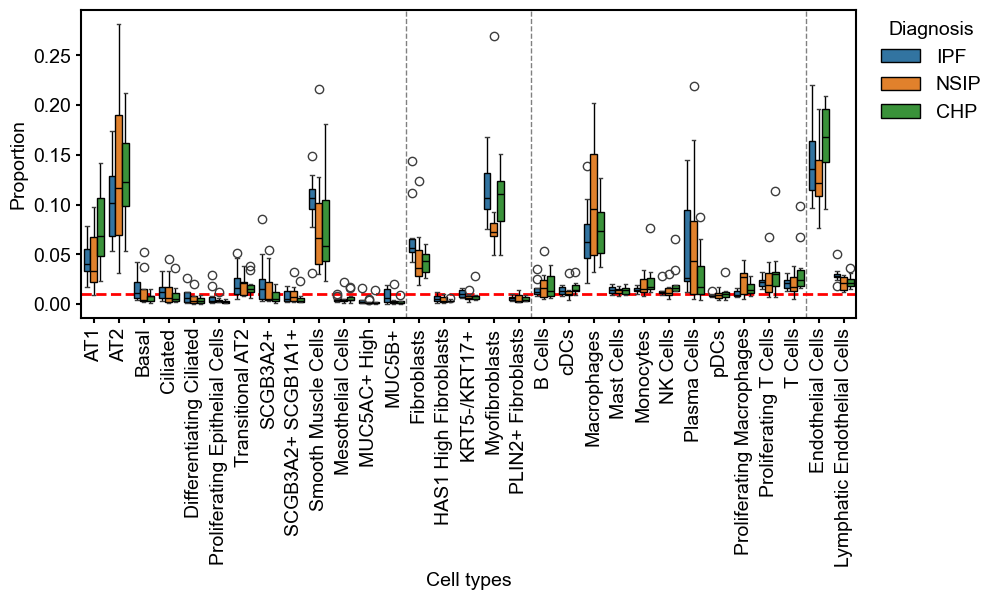

In [36]:
plt.figure(figsize = (10,4))
sns.boxplot(data=df_norm_cat_melt[df_norm_cat_melt["cond"]!="UNC"], x= "Cell types", y= "Normalized count", hue = "cond", hue_order=["IPF","NSIP","CHP"], order = cell_type_order,
            boxprops=boxprops, whiskerprops=whiskerprops, medianprops=medianprops)


plt.axhline(y = 0.01, color = 'red', ls = "--", zorder = 1)
# Add vertical lines between groups
for idx in group_split_indices:
    plt.axvline(x=idx - 0.5, color='gray', linestyle='--', linewidth=1, zorder=0)

plt.xticks(rotation=90)
plt.ylabel("Proportion")
plt.legend(title = "Diagnosis", loc = 'center left', bbox_to_anchor = (1.01, 0.8), frameon=False)
plt.savefig(os.path.join(save_dir, "normalized_count.png"), transparent=True, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, "normalized_count.svg"), transparent=True, bbox_inches='tight')
plt.savefig(os.path.join(save_dir, "normalized_count.pdf"), transparent=True, bbox_inches='tight')

In [37]:
# Step 1: Group and sum
grouped = df[df['cond']!='UNC'].groupby('library_id')[['AT2', 'AT1']].sum()

# Step 2: Compute ratio and assign a label
grouped['ratio'] = grouped['AT2'] / grouped['AT1']

# Step 3: Keep only the ratio column (optional) and reset index
ratio = grouped[['ratio']]

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_2696/918531539.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df[df['cond']!='UNC'].groupby('library_id')[['AT2', 'AT1']].sum()


In [38]:
ratio

,ratio
library_id,
06_30914_A1,2.115922
08_38774_B2,2.391483
11_13888_A1,1.215999
12_39986_A2,NaN
16_39724_B1,2.012558
16_46257_A1,NaN
16_53837_A10,NaN
17_25789_B1,1.713656
17_35291_B1,NaN


In [39]:
ratio_cat = pd.concat([cond, ratio], axis =1)

In [40]:
ratio_cat

,cond,ratio
library_id,,
06_30914_A1,NSIP,2.115922
08_38774_B2,CHP,2.391483
11_13888_A1,CHP,1.215999
12_39986_A2,UNC,NaN
16_39724_B1,CHP,2.012558
16_46257_A1,UNC,NaN
16_53837_A10,UNC,NaN
17_25789_B1,CHP,1.713656
17_35291_B1,UNC,NaN


In [41]:
boxprops=dict(edgecolor="black")
whiskerprops=dict(color="black")
capprops=dict(color='black')
medianprops=dict(color='black')
flierprops = dict(marker='x', markerfacecolor='lightgrey', markersize=1,
                  linestyle='none')

/var/folders/65/h4__q7c96m5bzl1ghzyzm_nh0000gn/T/ipykernel_2696/448904323.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


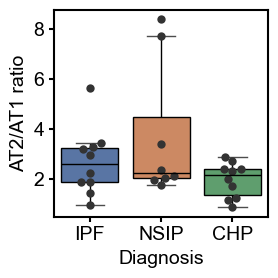

In [42]:
# Define the order you want
cond_order = ['IPF', 'NSIP', 'CHP']

# Use seaborn's 'deep' palette and select 3 colors
palette = sns.color_palette('deep', n_colors=3)


plt.figure(figsize=(3, 3))

# Create the boxplot
sns.boxplot(
    data=ratio_cat,
    x='cond',
    y='ratio',
    order=cond_order,
    palette=palette,
    flierprops=flierprops, boxprops=boxprops, whiskerprops=whiskerprops, medianprops=medianprops
)


# Scatter / strip plot (individual points)
sns.swarmplot(
    data=ratio_cat,
    x='cond',
    y='ratio',
    order=cond_order,
    color=".2",          # dark gray points
    size=6,
    zorder=2             # make sure points appear above the box
)


# Optional styling
plt.title('')
plt.xlabel('Diagnosis')
plt.ylabel('AT2/AT1 ratio')
plt.tight_layout()
plt.savefig(os.path.join(save_dir, "AT2_AT1_ratio.pdf"), transparent=True, bbox_inches='tight')
plt.show()

In [43]:
adata_vis.obs[ list(ct)].to_excel(os.path.join(save_dir,"Banovich_Kropski_2020_abs_cell_count.xlsx"))